# PU experiments

In [239]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_experiment import load_experiment_results 
import datetime 
from helpers import get_n_labels


In [240]:
EXPERIMENT = "label_mechanism"

In [241]:
df = load_experiment_results(name=EXPERIMENT,n=0)
df = df[df["model"]!="oracle"]
df.columns

Index(['label_mechanism', 'dataset', 'iter', 'model', 'accuracy',
       '0 precision', '1 precision', '0 recall', '1 recall', '0 f1', '1 f1',
       '0 support', '1 support', 'calculated_c', 'feature'],
      dtype='object')

In [242]:
df_c = load_experiment_results(name="c",n=0)
df_c = df_c[df_c["model"]!="oracle"]
# df_c[EXPERIMENT] = "SCAR_"+df_c["c"].round(2).astype(str)
df_c

,c,dataset,iter,model,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,1 f1,0 support,1 support,c log
0,0.01,mock,0,classic,0.600000,0.600000,0.000000,1.000000,0.000000,0.750000,0.000000,195,130,NaN
1,0.01,mock,0,naive,0.400000,0.000000,0.400000,0.000000,1.000000,0.000000,0.571429,195,130,NaN
3,0.01,mock,0,two_model,0.600000,0.600000,0.000000,1.000000,0.000000,0.750000,0.000000,195,130,NaN
4,0.01,mock,1,classic,0.600000,0.600000,0.000000,1.000000,0.000000,0.750000,0.000000,195,130,NaN
5,0.01,mock,1,naive,0.400000,0.000000,0.400000,0.000000,1.000000,0.000000,0.571429,195,130,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1913,1.00,mnist,8,naive,0.964196,0.966292,0.962016,0.963585,0.964835,0.964937,0.963424,1428,1365,NaN
1915,1.00,mnist,8,two_model,0.957035,0.964489,0.949458,0.950980,0.963370,0.957687,0.956364,1428,1365,NaN
1916,1.00,mnist,9,classic,0.968135,0.967855,0.968429,0.969888,0.966300,0.968870,0.967363,1428,1365,NaN
1917,1.00,mnist,9,naive,0.970641,0.973277,0.967907,0.969188,0.972161,0.971228,0.970029,1428,1365,NaN


In [243]:
df_c["precision"] = (df_c["0 precision"] + (df_c["1 precision"])) / 2
df_c["recall"] = (df_c["0 recall"] + (df_c["1 recall"])) / 2
df_c["f1"] = (df_c["0 f1"] + (df_c["1 f1"])) / 2

In [244]:
df["precision"] = (df["0 precision"]+df["1 precision"]) / 2
df["recall"] = (df["0 recall"]+df["1 recall"]) / 2
df["f1"] = (df["0 f1"]+df["1 f1"]) / 2

df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(4)
df[["precision","recall","f1"]].describe()

,precision,recall,f1
count,1560.000000,1560.000000,1560.000000
mean,0.620653,0.617167,0.557494
std,0.258716,0.207413,0.242362
min,0.000000,0.000000,0.000000
25%,0.414050,0.500000,0.375000
50%,0.690500,0.582350,0.538850
75%,0.792975,0.715425,0.706900
max,1.000000,1.000000,1.000000


In [245]:
fig_experiment_folder = EXPERIMENT
os.makedirs(fig_experiment_folder, exist_ok=True)
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
fig_folder = os.path.join(fig_experiment_folder, f"{current_time}")
os.makedirs(fig_folder, exist_ok=True)

In [246]:
experiments = df[EXPERIMENT].unique()
experiments = [val for val in experiments if (val.split("_")[1] == "1") and val.startswith("SAR")]
experiments
df_exp = df[df[EXPERIMENT].isin(experiments)]
c_exp = df_exp[[EXPERIMENT,"calculated_c"]].groupby(EXPERIMENT).max().reset_index()
c_exp = c_exp.sort_values(by="calculated_c")
c_exp

,label_mechanism,calculated_c
6,SAR_1_0.95,0.462617
5,SAR_1_0.9,0.514019
4,SAR_1_0.8,0.574766
3,SAR_1_0.6,0.691589
0,SAR_1_0.0,1.000000
1,SAR_1_0.2,1.000000
2,SAR_1_0.4,1.000000


In [247]:
df_c["c"] = df_c["c"].round(2)
C = df_c["c"].unique()
c_exp["calculated_c"] = c_exp["calculated_c"].round(2)
#find closest value in C for each row in c_exp
c_exp["c"] = c_exp["calculated_c"].apply(lambda x: min(C, key=lambda y: abs(y - x+0.015)))
c_exp
#add it to the df
df_c = df_c.merge(c_exp[["label_mechanism","c"]], on="c", how="left")


In [248]:
df_c = df_c.loc[df_c["c"].isin(c_exp["c"])]
df_c = df_c[["iter","model","dataset","c","label_mechanism","precision","recall","f1","accuracy"]]
df_c = df_c.rename(columns={"precision":"precision SCAR","recall":"recall SCAR","f1":"f1 SCAR","accuracy":"accuracy SCAR"})
df_exp = df_exp.merge(df_c, on=["model","dataset","iter","label_mechanism"], suffixes=('_orig', '_c'))
df_exp

,label_mechanism,dataset,iter,model,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,...,calculated_c,feature,precision,recall,f1,c,precision SCAR,recall SCAR,f1 SCAR,accuracy SCAR
0,SAR_1_0.0,mock,0,classic,0.618462,0.614148,0.714286,0.979487,0.076923,0.754941,...,1.000000,feature_0,0.6642,0.5282,0.4469,1.0,0.653336,0.555128,0.508758,0.633846
1,SAR_1_0.0,mock,0,naive,0.618462,0.614148,0.714286,0.979487,0.076923,0.754941,...,1.000000,feature_0,0.6642,0.5282,0.4469,1.0,0.598258,0.526923,0.371921,0.440000
2,SAR_1_0.0,mock,0,two_model,0.646154,0.838983,0.536232,0.507692,0.853846,0.632588,...,1.000000,feature_0,0.6876,0.6808,0.6457,1.0,0.687607,0.680769,0.645671,0.646154
3,SAR_1_0.0,mock,1,classic,0.670769,0.658273,0.744681,0.938462,0.269231,0.773784,...,1.000000,feature_1,0.7015,0.6038,0.5846,1.0,0.651131,0.612821,0.609136,0.661538
4,SAR_1_0.0,mock,1,naive,0.670769,0.656028,0.767442,0.948718,0.253846,0.775681,...,1.000000,feature_1,0.7117,0.6013,0.5786,1.0,0.648424,0.616667,0.614995,0.661538
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,SAR_1_0.95,mnist,8,naive,0.479413,0.494561,0.389578,0.827731,0.115018,0.619172,...,0.000000,pixel321,0.4421,0.4714,0.3984,0.4,0.948611,0.947759,0.948018,0.948084
836,SAR_1_0.95,mnist,8,two_model,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,,0.0000,0.0000,0.0000,0.4,0.895211,0.884071,0.884725,0.885786
837,SAR_1_0.95,mnist,9,classic,0.534551,0.523460,1.000000,1.000000,0.047619,0.687199,...,0.034615,pixel333,0.7617,0.5238,0.3891,0.4,0.796766,0.674553,0.642205,0.681704
838,SAR_1_0.95,mnist,9,naive,0.539563,0.529510,0.602067,0.892157,0.170696,0.664580,...,0.034615,pixel333,0.5658,0.5314,0.4653,0.4,0.950353,0.948648,0.949060,0.949159


In [249]:
df_exp["f1 diff"] = df_exp["f1"] - df_exp["f1 SCAR"]
df_exp["precision diff"] = df_exp["precision"] - df_exp["precision SCAR"]
df_exp["recall diff"] = df_exp["recall"] - df_exp["recall SCAR"]
df_exp["accuracy diff"] = df_exp["accuracy"] - df_exp["accuracy SCAR"]


In [250]:
df_exp = df_exp[(df_exp["model"]=="naive") | (df_exp["model"]=="two_model")]

df_exp_G = df_exp.drop(columns=["feature"]).groupby([EXPERIMENT,"model","dataset"]).mean().reset_index()


In [251]:
df_exp_G["model"] = df_exp_G["model"].astype(str)+ " difference with SCAR"

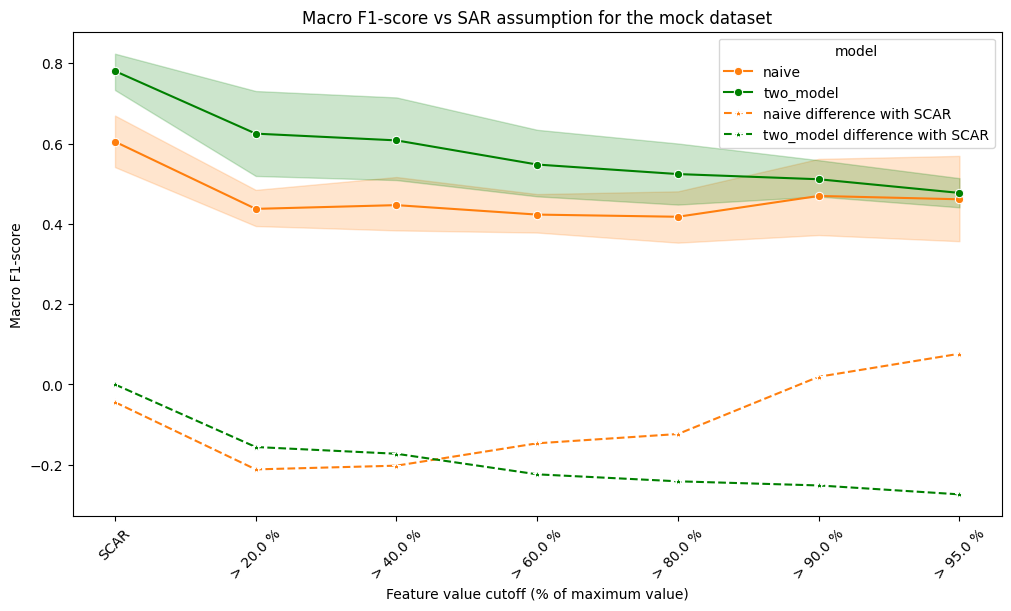

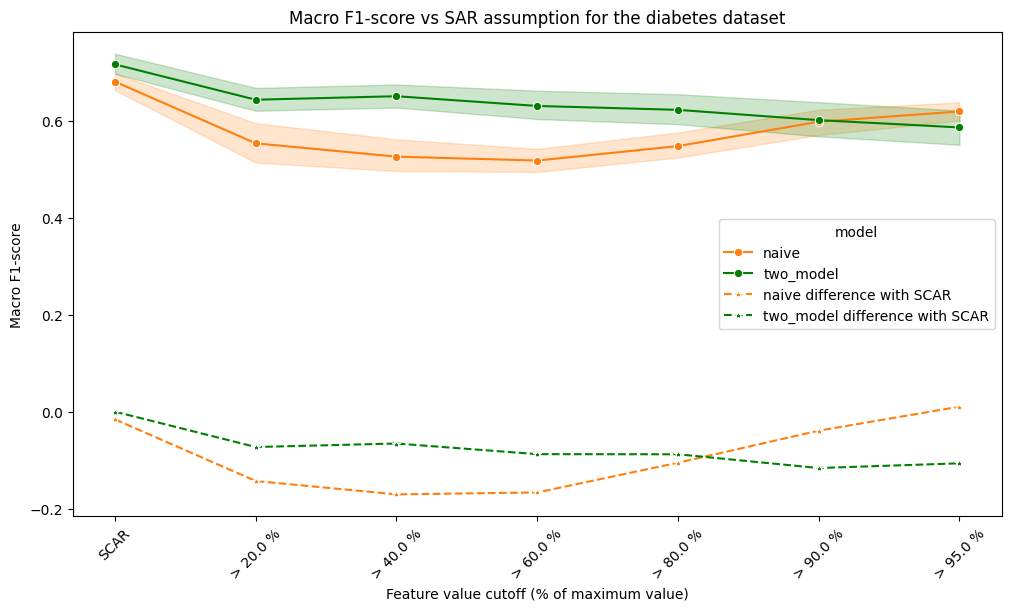

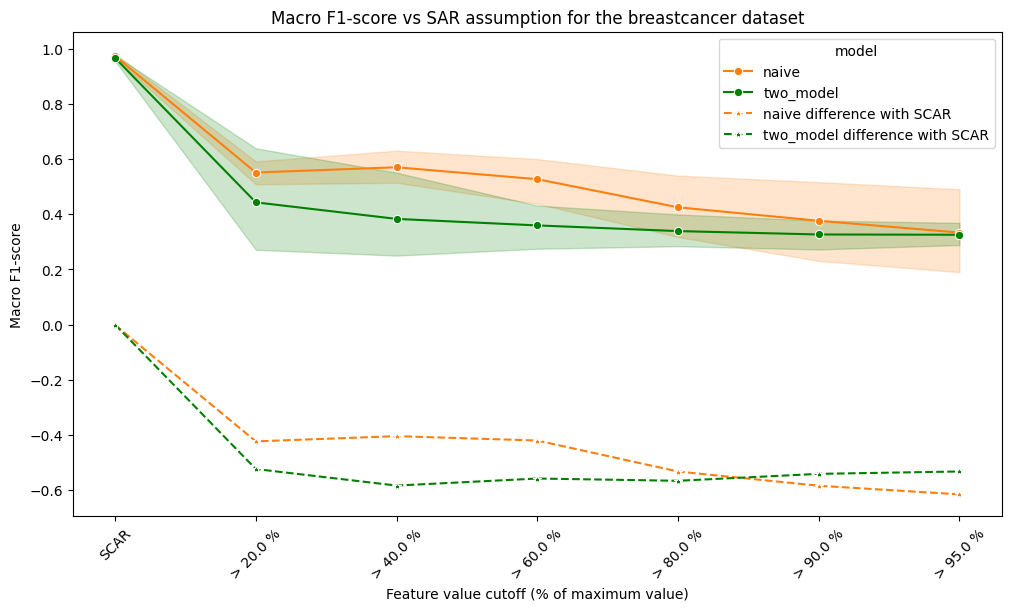

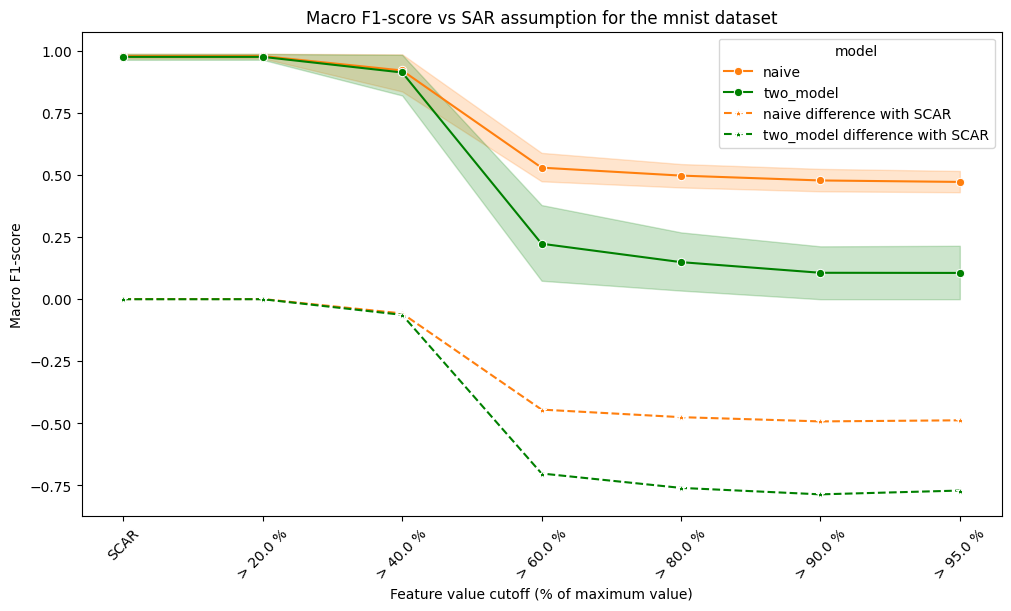

In [252]:

for dataset in df_exp["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    values = df_exp[df_exp["dataset"]==dataset][EXPERIMENT].unique()
    def plot_metric(metric="f1",name="Macro F1-score"):
        
        plt.figure(figsize=(10, 6),layout='constrained')
        sns.lineplot(data=df_exp[df_exp["dataset"]==dataset], x=EXPERIMENT,y=metric,marker="o",hue="model",palette=["C1",'green'])
        sns.lineplot(data=df_exp_G[df_exp_G["dataset"]==dataset], x=EXPERIMENT,y=f"{metric} diff",marker="*",hue="model",linestyle="--",palette=["C1",'green'])
        plt.title(f"{name} vs SAR assumption for the {dataset} dataset")
        plt.ylabel(name)
        ticks = [f"> {float(val.split('_')[2])*100} %" for val in experiments]
        ticks = ticks[1:]
        ticks.insert(0,"SCAR")
        plt.xticks(experiments, ticks,rotation=45)
        plt.xlabel("Feature value cutoff (% of maximum value)")
        plt.savefig(os.path.join(fig_folder,f"SAR_{name}_{dataset}.png"))
        plt.show()

    plot_metric(metric="f1",name="Macro F1-score")
    # plot_metric(metric="precision",name="Macro Precision")
    # plot_metric(metric="recall",name="Macro Recall")
    # plot_metric(metric="accuracy",name="Accuracy")



In [253]:
X = df["calculated_c"].round(1).sort_values()
X.unique()

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [254]:
df["label_mechanism"].unique()

array(['SCAR_1_1', 'SAR_1_0.0', 'SAR_1_0.2', 'SAR_1_0.4', 'SAR_1_0.6',
       'SAR_1_0.8', 'SAR_1_0.9', 'SAR_1_0.95', 'SAR_4_5', 'SAR_5_4',
       'casecontrol_0.5', 'casecontrol_0.75', 'casecontrol_0.9'],
      dtype=object)

In [255]:
experiments = df[EXPERIMENT].unique()
experiments = [val for val in experiments if (val == "casecontrol_0.9") or (val == "SAR_1_0.9")]
experiments = experiments[:2]
df_exp = df[df[EXPERIMENT].isin(experiments)]
df_exp.label_mechanism.unique()

array(['SAR_1_0.9', 'casecontrol_0.9'], dtype=object)

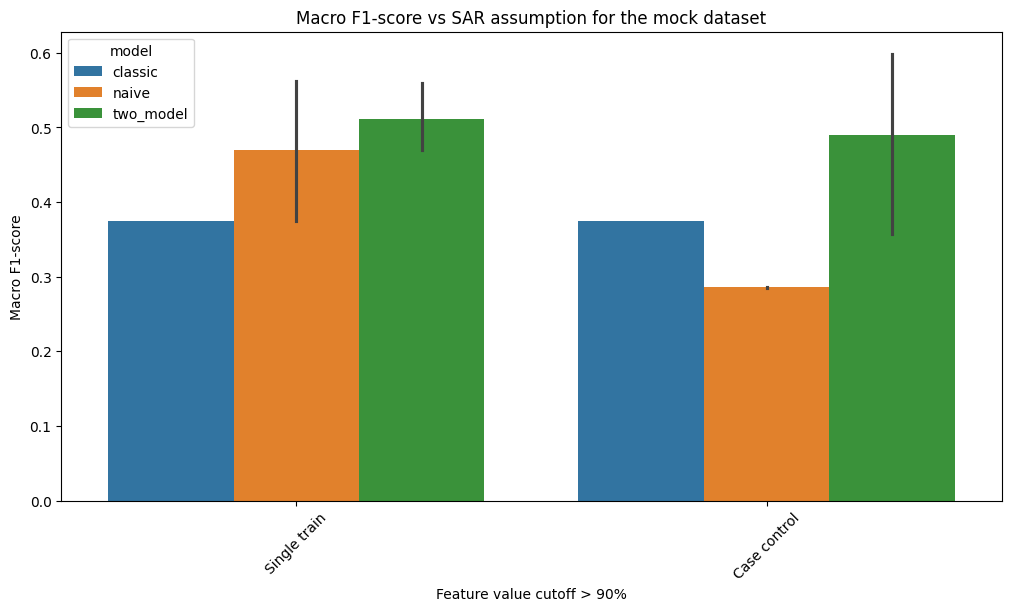

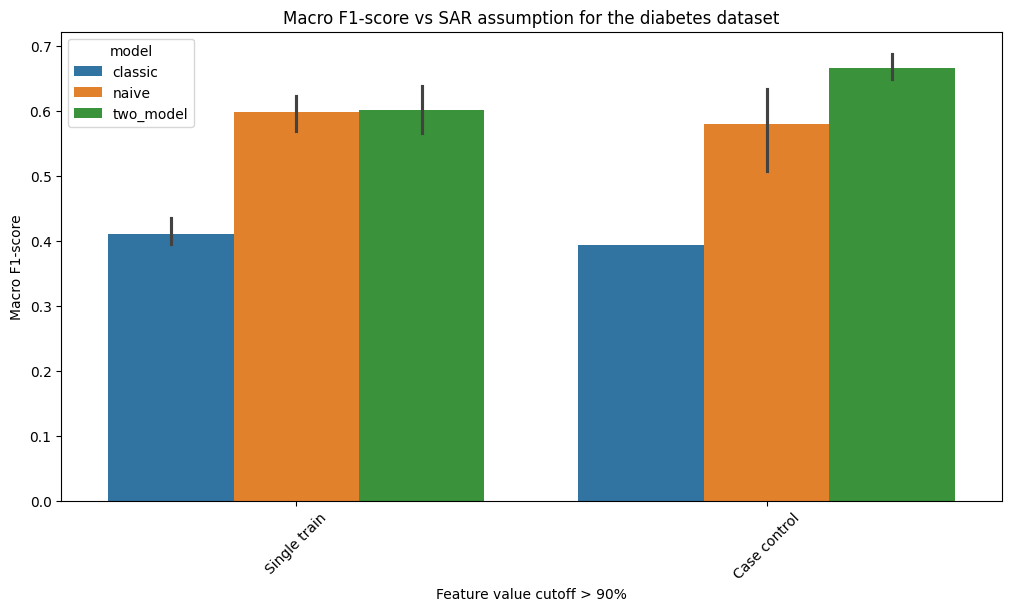

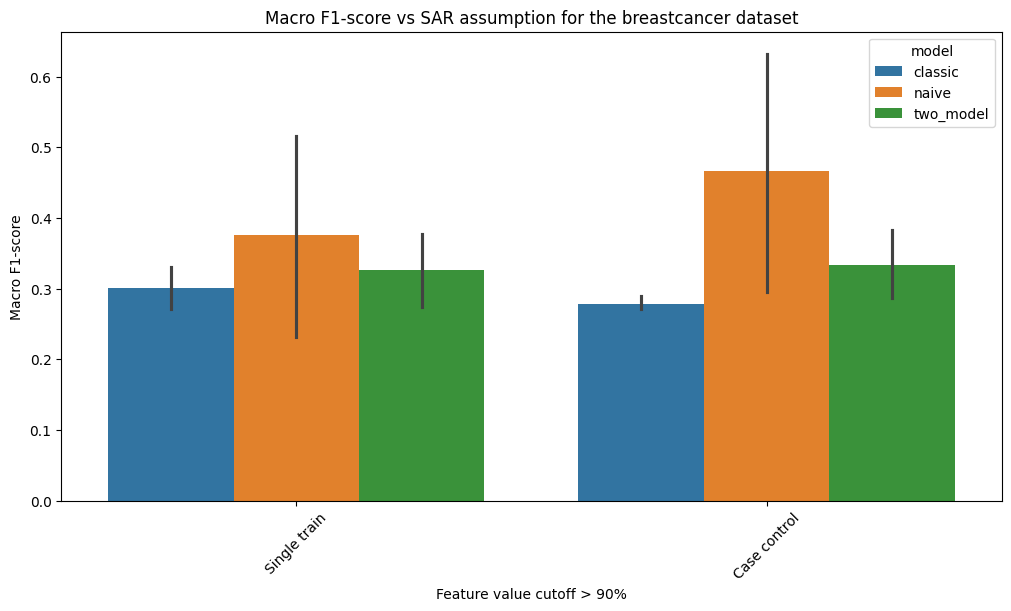

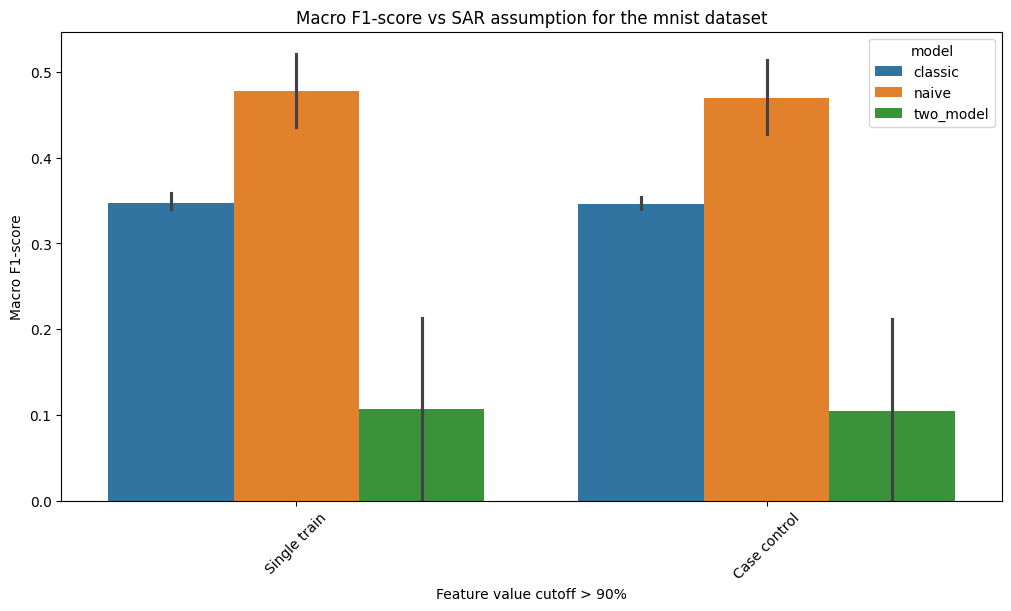

In [256]:

for dataset in df_exp["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    values = df_exp[df_exp["dataset"]==dataset][EXPERIMENT].unique()

    def plot_metric(metric="f1",name="Macro F1-score"):
        plt.figure(figsize=(10, 6),layout='constrained')
        sns.barplot(data=df_exp[df_exp["dataset"]==dataset], x=EXPERIMENT,y=metric,hue="model")
        plt.title(f"{name} vs SAR assumption for the {dataset} dataset")
        plt.ylabel(name)
        ticks = ["Single train", "Case control"]
        # ticks = ticks[1:]
        # ticks.insert(0,"single train")
        plt.xticks(experiments, ticks,rotation=45)
        plt.xlabel("Feature value cutoff > 90%")
        plt.savefig(os.path.join(fig_folder,f"CC_90_{name}_{dataset}.png"))
        plt.show()
    plot_metric(metric="f1",name="Macro F1-score")
    # plot_metric(metric="precision",name="Macro Precision")
    # plot_metric(metric="recall",name="Macro Recall")
    # plot_metric(metric="accuracy",name="Accuracy")
    
    

In [257]:
df[EXPERIMENT].unique()

array(['SCAR_1_1', 'SAR_1_0.0', 'SAR_1_0.2', 'SAR_1_0.4', 'SAR_1_0.6',
       'SAR_1_0.8', 'SAR_1_0.9', 'SAR_1_0.95', 'SAR_4_5', 'SAR_5_4',
       'casecontrol_0.5', 'casecontrol_0.75', 'casecontrol_0.9'],
      dtype=object)

In [258]:
experiments = df[EXPERIMENT].unique()
experiments = [val for val in experiments if (float(val.split("_")[1]) > 1 and val.startswith("SAR")) or val.startswith("SCAR")]
experiments
df_exp = df[df[EXPERIMENT].isin(experiments)]
experiments

['SCAR_1_1', 'SAR_4_5', 'SAR_5_4']

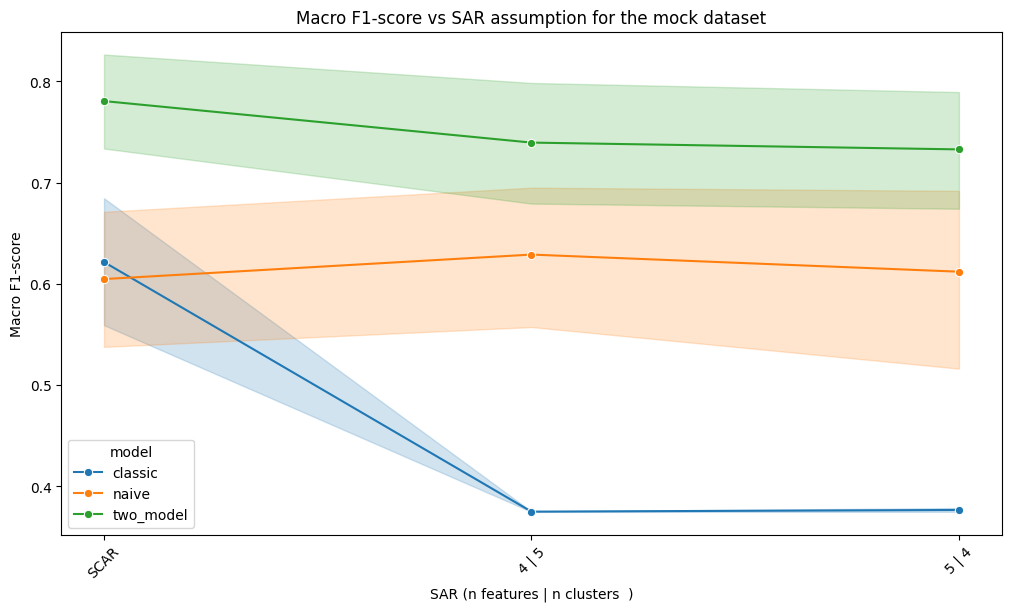

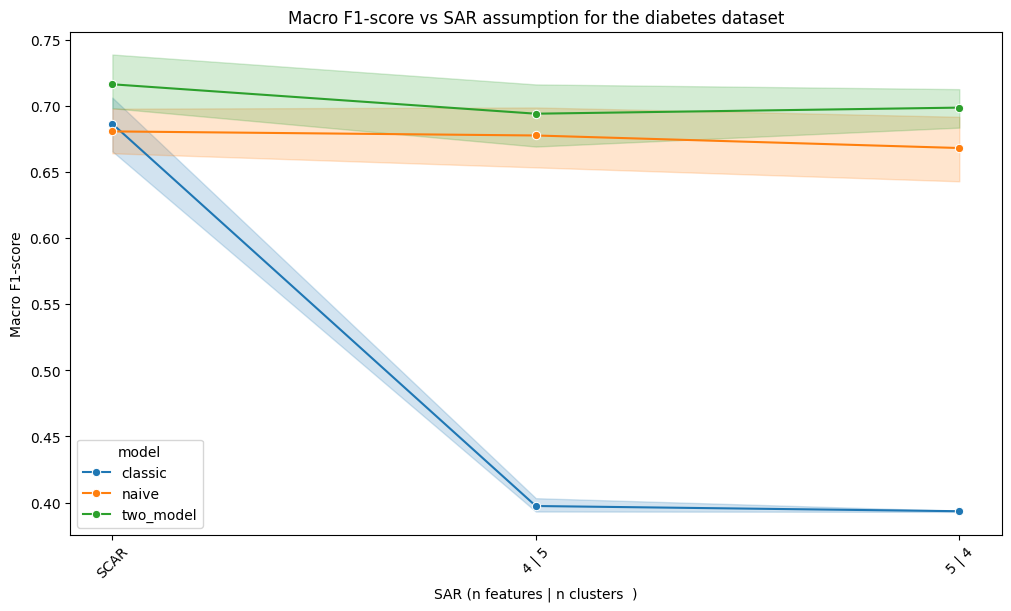

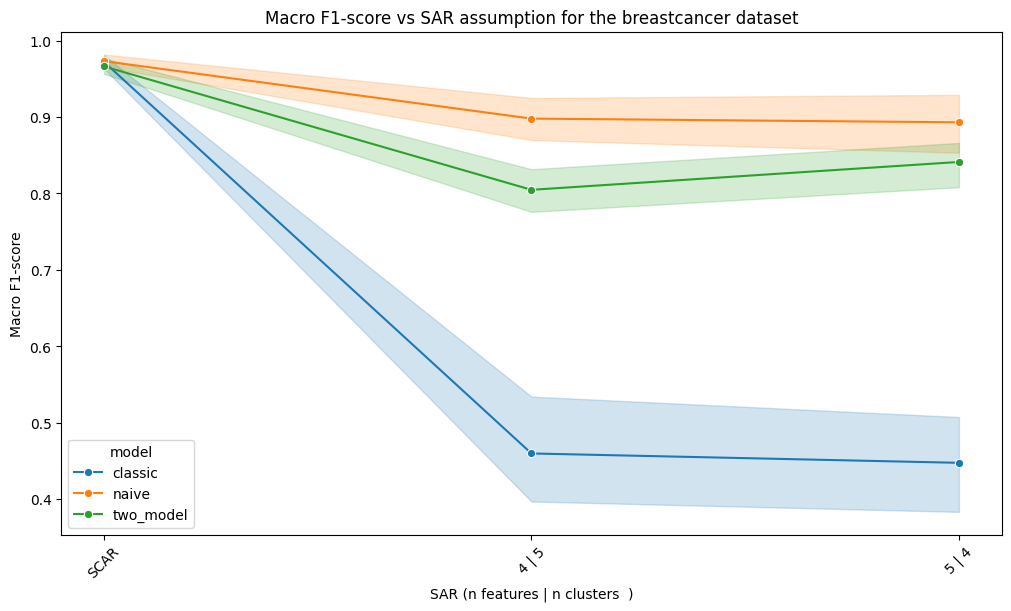

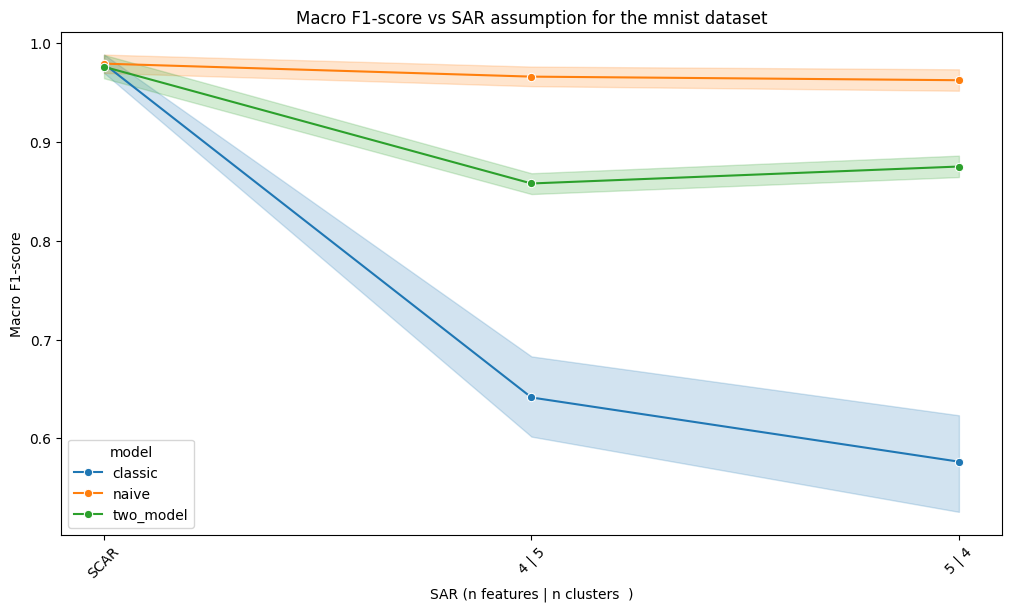

In [259]:
for dataset in df_exp["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    values = df_exp[df_exp["dataset"]==dataset][EXPERIMENT].unique()
    def plot_metric(metric="f1",name="Macro F1-score"):
        
        plt.figure(figsize=(10, 6),layout='constrained')
        sns.lineplot(data=df_exp[df_exp["dataset"]==dataset], x=EXPERIMENT,y=metric,marker="o",hue="model")
        plt.title(f"{name} vs SAR assumption for the {dataset} dataset")
        plt.ylabel(name)
        ticks = [f"{val.split('_')[1]} | {val.split('_')[2]}" for val in experiments]
        ticks = ticks[1:]
        ticks.insert(0,"SCAR")
        plt.xticks(experiments, ticks,rotation=45)
        plt.xlabel("SAR (n features | n clusters  )")
        plt.savefig(os.path.join(fig_folder,f"SAR_geo_mean_{name}_{dataset}.png"))
        plt.show()

    plot_metric(metric="f1",name="Macro F1-score")
    # plot_metric(metric="precision",name="Macro Precision")
    # plot_metric(metric="recall",name="Macro Recall")
    # plot_metric(metric="accuracy",name="Accuracy")